In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import time

from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
use_cuda = False
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 64

import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

In [ ]:
# loading the dataset
# note that this time we do not perfrom the normalization operation, see next cell
test_dataset = datasets.MNIST('mnist_data/', train=False, download=True, transform=transforms.Compose(
    [transforms.ToTensor()]
))

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]


In [ ]:
class Normalize(nn.Module):
    def forward(self, x):
        return (x - 0.1307) / 0.3081


class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=(5, 5))
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=(5, 5))
        self.bn2 = nn.BatchNorm2d(32)

        self.conv2_drop = nn.Dropout2d(p=0.2)

        self.fc1 = nn.Linear(128, 100)
        self.fc2 = nn.Linear(100, 10)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=(3, 3))
        self.bn3 = nn.BatchNorm2d(64)

        self.conv4 = nn.Conv2d(64, 64, kernel_size=(3, 3))
        self.bn4 = nn.BatchNorm2d(64)

        self.conv5 = nn.Conv2d(64, 128, kernel_size=(3, 3))
        self.bn5 = nn.BatchNorm2d(128)

        self.conv6 = nn.Conv2d(128, 128, kernel_size=(1, 1))
        self.bn6 = nn.BatchNorm2d(128)

    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = self.bn1(x)

        x = F.relu(self.conv2(x))
        x = self.conv2_drop(F.max_pool2d(self.bn2(x), 2))

        x = F.relu(self.conv3(x))
        x = self.bn3(x)

        x = F.relu(self.conv4(x))
        x = self.bn4(x)

        x = F.max_pool2d(x, 2)

        x = self.conv2_drop(x)

        x = F.relu(self.conv5(x))
        x = self.bn5(x)

        x = F.relu(self.conv6(x))
        x = self.bn6(x)

        size = x.size()[1] * x.size()[2] * x.size()[3]

        x = x.view(-1, size)

        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return x


with torch.serialization.safe_globals([ConvNet]):
    # first go to the files and uplode the "model.net"
    model = torch.load(
        "/content/model.net", # paste the path of the "model.net" where you have uploaded
        map_location="cpu",
        weights_only=False
    )


model = nn.Sequential(Normalize(), model)

model_to_prob = nn.Sequential(
    model,
    nn.Softmax(dim=1)
)

model.eval()
model_to_prob.eval()

/usr/local/lib/python3.12/dist-packages/torch/serialization.py:1782: UserWarning: Couldn't retrieve source code for container of type ConvNet. It won't be checked for correctness upon loading.
  _check_container_source(*data)
/usr/local/lib/python3.12/dist-packages/torch/serialization.py:1782: SourceChangeWarning: source code of class 'torch.nn.modules.conv.Conv2d' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  _check_container_source(*data)
/usr/local/lib/python3.12/dist-packages/torch/serialization.py:1782: SourceChangeWarning: source code of class 'torch.nn.modules.batchnorm.BatchNorm2d' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  _check_container_source(*data)
/usr/local/lib/python3.12/dist-packa

Sequential(
  (0): Sequential(
    (0): Normalize()
    (1): ConvNet(
      (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1))
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2_drop): Dropout2d(p=0.2, inplace=False)
      (fc1): Linear(in_features=128, out_features=100, bias=True)
      (fc2): Linear(in_features=100, out_features=10, bias=True)
      (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
      (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
      (bn5): BatchNorm2d(128, eps=1e-05, momentum=

In [ ]:
# define a show function for later
def show(original, adv, model_to_prob):
    p0 = model_to_prob(original).detach().numpy()
    p1 = model_to_prob(adv).detach().numpy()
    f, axarr = plt.subplots(1,2)
    axarr[0].imshow(original.detach().numpy().reshape(28, 28), cmap='gray')
    axarr[0].set_title("Original, class: " + str(p0.argmax()))
    axarr[1].imshow(adv.detach().numpy().reshape(28, 28), cmap='gray')
    axarr[1].set_title("Original, class: " + str(p1.argmax()))
    print("Class\t\tOrig\tAdv")
    for i in range(10):
        print("Class {}:\t{:.2f}\t{:.2f}".format(i, float(p0[:, i]), float(p1[:, i])))

In [ ]:
def fgsm_(model, x, target, eps, targeted=True, clip_min=None, clip_max=None):
    """Internal process for all FGSM and PGD attacks."""
    # create a copy of the input, remove all previous associations to the compute graph...
    input_ = x.clone().detach_()
    # ... and make sure we are differentiating toward that variable
    input_.requires_grad_()

    # run the model and obtain the loss
    logits = model(input_)
    target = torch.LongTensor([target])
    model.zero_grad()
    loss = nn.CrossEntropyLoss()(logits, target)
    loss.backward()

    #perfrom either targeted or untargeted attack
    if targeted:
        out = input_ - eps * input_.grad.sign()
    else:
        out = input_ + eps * input_.grad.sign()

    #if desired clip the ouput back to the image domain
    if (clip_min is not None) or (clip_max is not None):
        out.clamp_(min=clip_min, max=clip_max)
    return out

def fgsm_targeted(model, x, target, eps, **kwargs):
    return fgsm_(model, x, target, eps, targeted=True, **kwargs)

def fgsm_untargeted(model, x, label, eps, **kwargs):
    return fgsm_(model, x, label, eps, targeted=False, **kwargs)


def pgd_(model, x, target, k, eps, eps_step, targeted=True, clip_min=None, clip_max=None):
    x_min = x - eps
    x_max = x + eps

    # Randomize the starting point x.
    x = x + eps * (2 * torch.rand_like(x) - 1)
    if (clip_min is not None) or (clip_max is not None):
        x.clamp_(min=clip_min, max=clip_max)

    for i in range(k):
        # FGSM step
        # We don't clamp here (arguments clip_min=None, clip_max=None)
        # as we want to apply the attack as defined
        x = fgsm_(model, x, target, eps_step, targeted)
        # Projection Step
        x = torch.max(x_min, x)
        x = torch.min(x_max, x)
    #if desired clip the ouput back to the image domain
    if (clip_min is not None) or (clip_max is not None):
        x.clamp_(min=clip_min, max=clip_max)
    return x

def pgd_targeted(model, x, target, k, eps, eps_step, clip_min=None, clip_max=None, **kwargs):
    return pgd_(model, x, target, k, eps, eps_step, targeted=True, **kwargs)

def pgd_untargeted(model, x, label, k, eps, eps_step, clip_min=None, clip_max=None, **kwargs):
    return pgd_(model, x, label, k, eps, eps_step, targeted=False, **kwargs)

Class		Orig	Adv
Class 0:	0.00	0.00
Class 1:	0.00	0.00
Class 2:	0.00	0.00
Class 3:	0.00	0.00
Class 4:	0.00	0.73
Class 5:	0.00	0.01
Class 6:	1.00	0.26
Class 7:	0.00	0.00
Class 8:	0.00	0.00
Class 9:	0.00	0.00


/tmp/ipykernel_442/3779733790.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Class {}:\t{:.2f}\t{:.2f}".format(i, float(p0[:, i]), float(p1[:, i])))


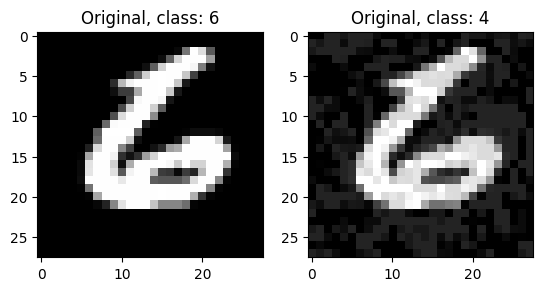

In [ ]:
# try out our attacks
original = torch.unsqueeze(test_dataset[9999][0], dim=0)

#adv = fgsm_untargeted(model, original, label=7, eps=0.25, clip_min=0, clip_max=1.0)
#adv = fgsm_targeted(model, original, target=3, eps=0.2, clip_min=0, clip_max=1.0)

#adv = pgd_untargeted(model, original, label=7, k=10, eps=0.08, eps_step=0.05, clip_min=0, clip_max=1.0)
adv = pgd_targeted(model, original, target=4, k=10, eps=0.08, eps_step=0.05, clip_min=0, clip_max=1.0)

show(original, adv, model_to_prob)

In [ ]:
# iterate through first 10 images of test_dataset
for i, (image, label) in enumerate(test_dataset):

    print("Index:", i)
    print("Label:", label)
    # print("Shape:", image.shape)

    # plt.imshow(image.squeeze(), cmap='gray')
    # plt.title(f"Index: {i}, Label: {label}")
    # plt.show()

    # # stop after 10 images
    # if i == 9:
    #     break

Streaming output truncated to the last 5000 lines.
Index: 7500
Label: 8
Index: 7501
Label: 3
Index: 7502
Label: 8
Index: 7503
Label: 6
Index: 7504
Label: 7
Index: 7505
Label: 0
Index: 7506
Label: 0
Index: 7507
Label: 1
Index: 7508
Label: 2
Index: 7509
Label: 3
Index: 7510
Label: 4
Index: 7511
Label: 5
Index: 7512
Label: 6
Index: 7513
Label: 7
Index: 7514
Label: 8
Index: 7515
Label: 9
Index: 7516
Label: 0
Index: 7517
Label: 1
Index: 7518
Label: 2
Index: 7519
Label: 3
Index: 7520
Label: 4
Index: 7521
Label: 5
Index: 7522
Label: 6
Index: 7523
Label: 7
Index: 7524
Label: 8
Index: 7525
Label: 9
Index: 7526
Label: 0
Index: 7527
Label: 1
Index: 7528
Label: 2
Index: 7529
Label: 3
Index: 7530
Label: 4
Index: 7531
Label: 5
Index: 7532
Label: 6
Index: 7533
Label: 7
Index: 7534
Label: 8
Index: 7535
Label: 9
Index: 7536
Label: 0
Index: 7537
Label: 0
Index: 7538
Label: 7
Index: 7539
Label: 2
Index: 7540
Label: 6
Index: 7541
Label: 5
Index: 7542
Label: 5
Index: 7543
Label: 3
Index: 7544
Label: 7
Inde

# **ROTATION BASED**

In [ ]:
# ======================================================================
# ROTATION-BASED ADVERSARIAL ATTACKS  — FGSM & PGD
# ======================================================================
#
#  CONCEPT: Two "attributes" we can attack
#  ┌──────────────────┬─────────────────────────────────────────────────┐
#  │  Pixel attack    │  attribute = 784 pixel values in [0, 1]         │
#  │                  │  perturb:  Δx  bounded by ε                     │
#  │                  │  gradient: ∇_x  L  (784-dim)                    │
#  ├──────────────────┼─────────────────────────────────────────────────┤
#  │  Rotation attack │  attribute = 1 rotation angle θ in degrees      │
#  │                  │  perturb:  Δθ  bounded by ε_deg                 │
#  │                  │  gradient: ∇_θ  L  (1-dim)                      │
#  └──────────────────┴─────────────────────────────────────────────────┘
#
#  The math is identical — only what we differentiate w.r.t. changes.
#
# ======================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt


# ─────────────────────────────────────────────────────────────────────
# HELPER ─ Differentiable Rotation
# ─────────────────────────────────────────────────────────────────────

def rotate_image(x, angle_deg):
    """
    Rotate image `x` by `angle_deg` degrees using a differentiable
    affine transform (affine_grid + grid_sample).

    Why differentiable?  So we can call loss.backward() and get
    ∇_θ L — the gradient of the loss w.r.t. the rotation angle.
    This is exactly what FGSM/PGD need.

    Args:
        x         : Tensor (1, C, H, W)
        angle_deg : Scalar. Python float  OR  torch.Tensor with
                    requires_grad=True (used during the attack).
    Returns:
        Rotated image, same shape as x.
    """
    device = x.device

    if not isinstance(angle_deg, torch.Tensor):
        angle_deg = torch.tensor(float(angle_deg), dtype=torch.float32,
                                  device=device)
    else:
        angle_deg = angle_deg.to(device)

    angle_rad = angle_deg * (np.pi / 180.0)

    cos_a = torch.cos(angle_rad).reshape(1)          # shape (1,)
    sin_a = torch.sin(angle_rad).reshape(1)
    zero  = torch.zeros(1, dtype=torch.float32, device=device)

    # Rotation affine matrix  [[cos θ, -sin θ, 0],
    #                           [sin θ,  cos θ, 0]]
    row1  = torch.cat([ cos_a, -sin_a, zero])        # (3,)
    row2  = torch.cat([ sin_a,  cos_a, zero])
    theta = torch.stack([row1, row2]).unsqueeze(0)   # (1, 2, 3)

    # Build sampling grid and warp the image
    grid    = F.affine_grid(theta, x.size(), align_corners=False)
    rotated = F.grid_sample(x, grid, align_corners=False,
                             padding_mode='zeros')
    return rotated


# ─────────────────────────────────────────────────────────────────────
# FGSM ─ Core (mirrors fgsm_ from the original notebook)
# ─────────────────────────────────────────────────────────────────────

def fgsm_rotation_(model, x, target, eps_deg,
                    targeted=True,
                    clip_min_deg=None, clip_max_deg=None):
    """
    One FGSM step on the rotation angle θ.

    Pixel FGSM:    x_adv  = x  ±  ε  * sign(∇_x  L)
    Rotation FGSM: θ_adv  = 0  ±  ε° * sign(∇_θ  L)   (starts at θ=0)

    Args:
        model        : Neural network
        x            : Clean image, shape (1, C, H, W)
        target       : Target class (targeted) or true label (untargeted)
        eps_deg      : Rotation budget in degrees  (e.g. 30.0)
        targeted     : True  → minimise loss (push toward target class)
                       False → maximise loss (push away from true label)
        clip_min_deg : Optional hard lower bound on final angle
        clip_max_deg : Optional hard upper bound on final angle

    Returns:
        adv       : Adversarially rotated image, shape (1, C, H, W)
        angle_adv : The adversarial angle in degrees (Python float)
    """
    # θ starts at 0  (no rotation)
    angle = torch.tensor(0.0, requires_grad=True, dtype=torch.float32)

    # ── Forward pass ────────────────────────────────────────────────
    rotated  = rotate_image(x, angle)
    logits   = model(rotated)
    target_t = torch.LongTensor([target])
    model.zero_grad()
    loss     = nn.CrossEntropyLoss()(logits, target_t)
    loss.backward()
    # angle.grad now holds ∇_θ L

    # ── Gradient step on θ ──────────────────────────────────────────
    with torch.no_grad():
        if targeted:
            angle_adv = angle - eps_deg * angle.grad.sign()   # minimise loss
        else:
            angle_adv = angle + eps_deg * angle.grad.sign()   # maximise loss

        if clip_min_deg is not None or clip_max_deg is not None:
            lo = clip_min_deg if clip_min_deg is not None else -float('inf')
            hi = clip_max_deg if clip_max_deg is not None else  float('inf')
            angle_adv = angle_adv.clamp(lo, hi)

    adv = rotate_image(x.detach(), angle_adv).detach()
    return adv, angle_adv.item()


# ── Convenience wrappers (same naming style as original notebook) ────

def fgsm_rotation_targeted(model, x, target, eps_deg, **kwargs):
    """FGSM rotation: steer prediction toward `target` class."""
    return fgsm_rotation_(model, x, target, eps_deg, targeted=True, **kwargs)

def fgsm_rotation_untargeted(model, x, label, eps_deg, **kwargs):
    """FGSM rotation: steer prediction away from true `label`."""
    return fgsm_rotation_(model, x, label, eps_deg, targeted=False, **kwargs)


# ─────────────────────────────────────────────────────────────────────
# PGD ─ Core (mirrors pgd_ from the original notebook)
# ─────────────────────────────────────────────────────────────────────

def pgd_rotation_(model, x, target, k, eps_deg, eps_step_deg,
                   targeted=True,
                   clip_min_deg=None, clip_max_deg=None):
    """
    PGD on the rotation angle θ.

    Pixel PGD (recap):
      1. Randomise x within the ε-ball
      2. for k steps:
           a. FGSM step (size eps_step)
           b. Project x back into the ε-ball  (clamp pixel-wise)

    Rotation PGD (same logic, 1-D):
      1. Randomise θ  within [-ε°, +ε°]
      2. for k steps:
           a. FGSM step on θ  (size eps_step_deg)
           b. Project θ back into [-ε°, +ε°]  (scalar clamp)

    Args:
        model        : Neural network
        x            : Clean image, shape (1, C, H, W)
        target       : Target class (targeted) or true label (untargeted)
        k            : Number of PGD iterations
        eps_deg      : Total rotation budget in degrees  (e.g. 30.0)
        eps_step_deg : Per-iteration step size in degrees (e.g. 3.0)
        targeted     : Targeted or untargeted attack
        clip_min_deg : Optional hard lower bound on angle
        clip_max_deg : Optional hard upper bound on angle

    Returns:
        adv       : Adversarially rotated image, shape (1, C, H, W)
        angle_adv : Final adversarial angle in degrees (Python float)
    """
    angle_lo = -eps_deg
    angle_hi =  eps_deg

    # ── Random start within [-ε°, +ε°] ─────────────────────────────
    angle = torch.FloatTensor(1).uniform_(angle_lo, angle_hi)

    # ── k FGSM steps + projection ───────────────────────────────────
    for _ in range(k):
        angle_var = angle.clone().detach().requires_grad_(True)

        rotated  = rotate_image(x, angle_var)
        logits   = model(rotated)
        target_t = torch.LongTensor([target])
        model.zero_grad()
        loss     = nn.CrossEntropyLoss()(logits, target_t)
        loss.backward()

        with torch.no_grad():
            if targeted:
                angle = angle_var - eps_step_deg * angle_var.grad.sign()
            else:
                angle = angle_var + eps_step_deg * angle_var.grad.sign()

            # Projection: keep θ inside [-ε°, +ε°]
            angle = angle.clamp(angle_lo, angle_hi)

    # ── Optional hard clip ──────────────────────────────────────────
    if clip_min_deg is not None or clip_max_deg is not None:
        lo = clip_min_deg if clip_min_deg is not None else -float('inf')
        hi = clip_max_deg if clip_max_deg is not None else  float('inf')
        angle = angle.clamp(lo, hi)

    adv = rotate_image(x.detach(), angle.detach()).detach()
    return adv, angle.item()


# ── Convenience wrappers ─────────────────────────────────────────────

def pgd_rotation_targeted(model, x, target, k, eps_deg, eps_step_deg, **kwargs):
    """PGD rotation: steer prediction toward `target` class."""
    return pgd_rotation_(model, x, target, k, eps_deg, eps_step_deg,
                          targeted=True, **kwargs)

def pgd_rotation_untargeted(model, x, label, k, eps_deg, eps_step_deg, **kwargs):
    """PGD rotation: steer prediction away from true `label`."""
    return pgd_rotation_(model, x, label, k, eps_deg, eps_step_deg,
                          targeted=False, **kwargs)


# ─────────────────────────────────────────────────────────────────────
# Visualization
# ─────────────────────────────────────────────────────────────────────

def show_rotation(original, adv, angle_deg, model_to_prob, title=""):
    """
    Side-by-side: original vs adversarially rotated image.
    Mirrors the show() function from the original notebook.
    """
    p0 = model_to_prob(original).detach().numpy()
    p1 = model_to_prob(adv).detach().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(original.detach().numpy().reshape(28, 28), cmap='gray')
    axes[0].set_title(f"Original\nPredicted class: {p0.argmax()}", fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(adv.detach().numpy().reshape(28, 28), cmap='gray')
    axes[1].set_title(
        f"Adversarial rotation ({angle_deg:+.2f}°)\nPredicted class: {p1.argmax()}",
        fontsize=12
    )
    axes[1].axis('off')

    if title:
        plt.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ── Probability table ────────────────────────────────────────────
    print(f"  Adversarial angle : {angle_deg:+.4f}°")
    print(f"\n  {'Class':<8} {'Original':>10}  {'Rotated':>10}")
    print("  " + "─" * 35)
    for i in range(10):
        orig_tag = " ◄ true" if i == p0.argmax() else ""
        adv_tag  = " ◄ adv"  if i == p1.argmax() else ""
        print(f"  Class {i}:  {float(p0[:, i]):>8.2f}{orig_tag:10s}"
              f"  {float(p1[:, i]):>8.2f}{adv_tag}")
    print()




True label of selected image: 7



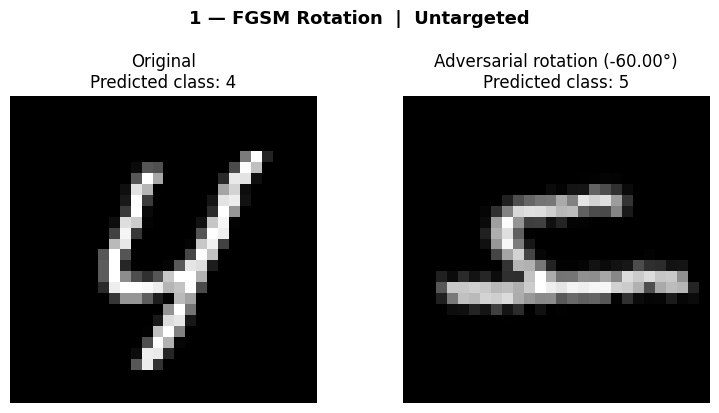

  Adversarial angle : -60.0000°

  Class      Original     Rotated
  ───────────────────────────────────
  Class 0:      0.00                0.00
  Class 1:      0.00                0.00
  Class 2:      0.00                0.01
  Class 3:      0.00                0.00
  Class 4:      1.00 ◄ true         0.00
  Class 5:      0.00                0.80 ◄ adv
  Class 6:      0.00                0.01
  Class 7:      0.00                0.00
  Class 8:      0.00                0.17
  Class 9:      0.00                0.00



/tmp/ipykernel_442/1205588638.py:263: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"  Class {i}:  {float(p0[:, i]):>8.2f}{orig_tag:10s}"
/tmp/ipykernel_442/1205588638.py:264: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"  {float(p1[:, i]):>8.2f}{adv_tag}")


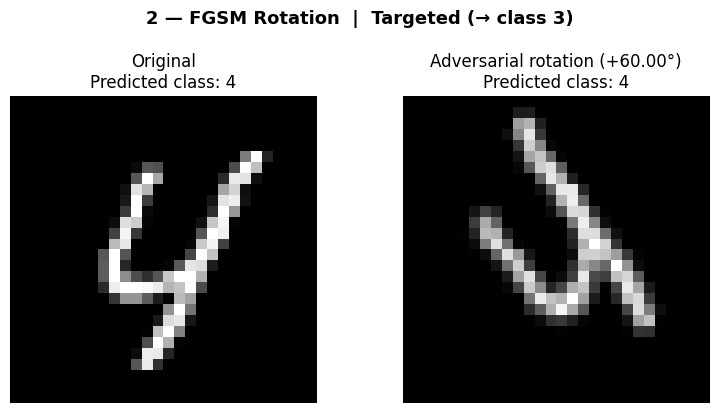

  Adversarial angle : +60.0000°

  Class      Original     Rotated
  ───────────────────────────────────
  Class 0:      0.00                0.01
  Class 1:      0.00                0.00
  Class 2:      0.00                0.44
  Class 3:      0.00                0.00
  Class 4:      1.00 ◄ true         0.50 ◄ adv
  Class 5:      0.00                0.00
  Class 6:      0.00                0.02
  Class 7:      0.00                0.00
  Class 8:      0.00                0.00
  Class 9:      0.00                0.03



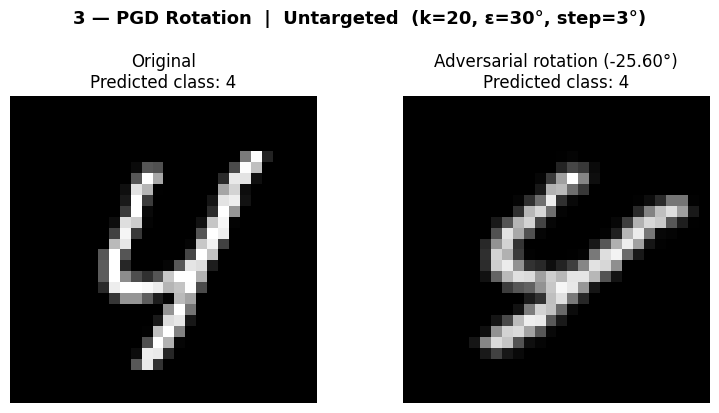

  Adversarial angle : -25.6043°

  Class      Original     Rotated
  ───────────────────────────────────
  Class 0:      0.00                0.00
  Class 1:      0.00                0.00
  Class 2:      0.00                0.00
  Class 3:      0.00                0.00
  Class 4:      1.00 ◄ true         1.00 ◄ adv
  Class 5:      0.00                0.00
  Class 6:      0.00                0.00
  Class 7:      0.00                0.00
  Class 8:      0.00                0.00
  Class 9:      0.00                0.00



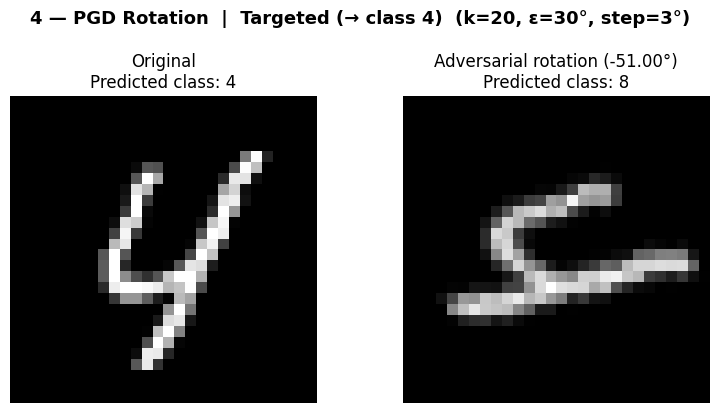

  Adversarial angle : -51.0000°

  Class      Original     Rotated
  ───────────────────────────────────
  Class 0:      0.00                0.00
  Class 1:      0.00                0.00
  Class 2:      0.00                0.00
  Class 3:      0.00                0.00
  Class 4:      1.00 ◄ true         0.00
  Class 5:      0.00                0.12
  Class 6:      0.00                0.02
  Class 7:      0.00                0.00
  Class 8:      0.00                0.85 ◄ adv
  Class 9:      0.00                0.00



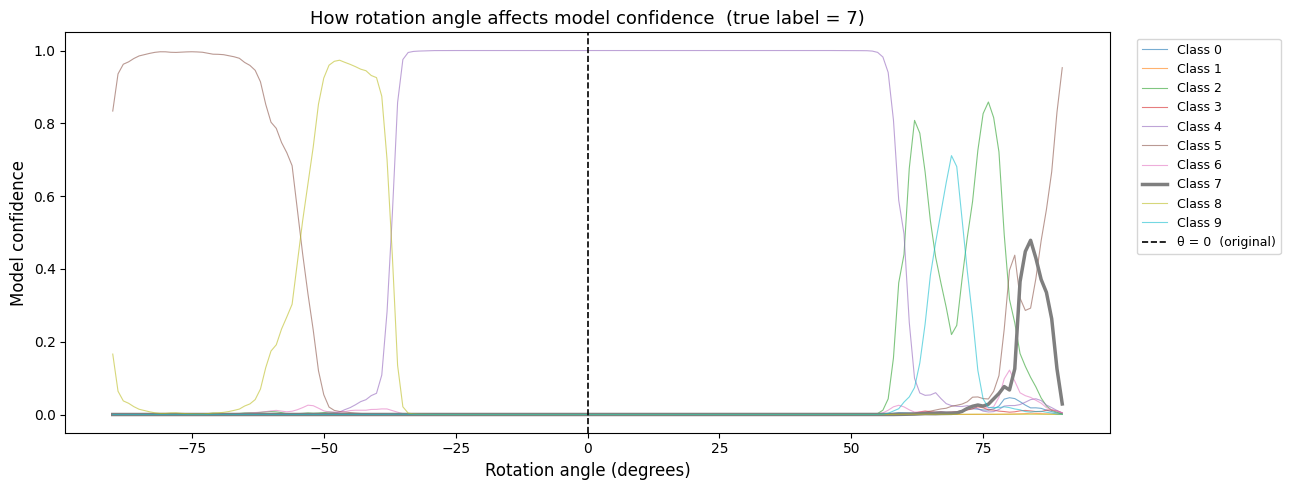

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# DEMO ─ Run all four rotation attacks
# ─────────────────────────────────────────────────────────────────────

original   = torch.unsqueeze(test_dataset[555][0], dim=0)
true_label = test_dataset[0][1]
print(f"True label of selected image: {true_label}\n")
print("=" * 60)

# ── 1. FGSM Untargeted ───────────────────────────────────────────────
# Find the rotation direction that moves prediction AWAY from true label
adv, angle = fgsm_rotation_untargeted(
    model, original,
    label   = true_label,
    eps_deg = 60.0          # max ±30° rotation
)
show_rotation(original, adv, angle, model_to_prob,
              title="1 — FGSM Rotation  |  Untargeted")

# ── 2. FGSM Targeted ─────────────────────────────────────────────────
# Find the rotation that pushes prediction toward class 3
adv, angle = fgsm_rotation_targeted(
    model, original,
    target  = 3,
    eps_deg = 60.0
)
show_rotation(original, adv, angle, model_to_prob,
              title="2 — FGSM Rotation  |  Targeted (→ class 3)")

# ── 3. PGD Untargeted ────────────────────────────────────────────────
# Iteratively refine the angle over 20 steps to maximise misclassification
adv, angle = pgd_rotation_untargeted(
    model, original,
    label        = true_label,
    k            = 20,      # number of PGD iterations
    eps_deg      = 60.0,    # max ±30° total
    eps_step_deg = 3.0      # 3° per step
)
show_rotation(original, adv, angle, model_to_prob,
              title="3 — PGD Rotation  |  Untargeted  (k=20, ε=30°, step=3°)")

# ── 4. PGD Targeted ──────────────────────────────────────────────────
# Iteratively steer toward class 4
adv, angle = pgd_rotation_targeted(
    model, original,
    target       = 4,
    k            = 20,
    eps_deg      = 60.0,
    eps_step_deg = 3.0
)
show_rotation(original, adv, angle, model_to_prob,
              title="4 — PGD Rotation  |  Targeted (→ class 4)  (k=20, ε=30°, step=3°)")


# ─────────────────────────────────────────────────────────────────────
# BONUS ─ Rotation Sensitivity Sweep
# ─────────────────────────────────────────────────────────────────────
# Sweep θ from -90° to +90° and record the model's class probabilities.
# This gives intuition for WHY certain rotation angles fool the model.
# ─────────────────────────────────────────────────────────────────────

angles          = np.linspace(-90, 90, 181)   # 1° resolution
probs_at_angles = np.zeros((len(angles), 10))

with torch.no_grad():
    for i, a in enumerate(angles):
        rotated             = rotate_image(original, a)
        probs_at_angles[i]  = model_to_prob(rotated).numpy()

plt.figure(figsize=(13, 5))
for cls in range(10):
    lw    = 2.5 if cls == true_label else 0.8
    alpha = 1.0 if cls == true_label else 0.6
    plt.plot(angles, probs_at_angles[:, cls],
             label=f"Class {cls}", linewidth=lw, alpha=alpha)

plt.axvline(0, color='black', linestyle='--', linewidth=1.2,
            label='θ = 0  (original)')
plt.xlabel("Rotation angle (degrees)", fontsize=12)
plt.ylabel("Model confidence", fontsize=12)
plt.title(
    f"How rotation angle affects model confidence  "
    f"(true label = {true_label})",
    fontsize=13
)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# **Combined**

Selected image true label: 5

▶  FGSM UNTARGETED — Pixel vs Rotation vs Combined



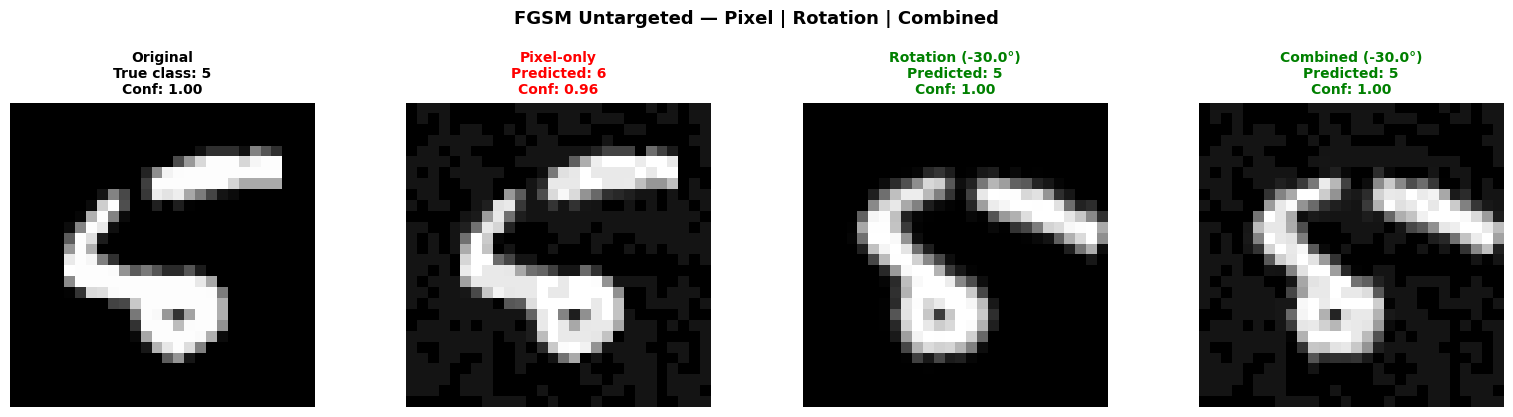


  Class      Original      Pixel   Rotation   Combined
  ───────────────────────────────────────────────────────
  Class 0:      0.00       0.00       0.00       0.00
  Class 1:      0.00       0.00       0.00       0.00
  Class 2:      0.00       0.00       0.00       0.00
  Class 3:      0.00       0.00       0.00       0.00
  Class 4:      0.00       0.00       0.00       0.00
  Class 5:      1.00       0.04       1.00       1.00 ◄ true
  Class 6:      0.00       0.96       0.00       0.00
  Class 7:      0.00       0.00       0.00       0.00
  Class 8:      0.00       0.00       0.00       0.00
  Class 9:      0.00       0.00       0.00       0.00


▶  PGD UNTARGETED — Pixel vs Rotation vs Combined



/tmp/ipykernel_442/1608255753.py:388: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"{float(p0[:,i]):>9.2f} "
/tmp/ipykernel_442/1608255753.py:389: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"{float(p_px[:,i]):>10.2f} "
/tmp/ipykernel_442/1608255753.py:390: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"{float(p_ro[:,i]):>10.2f} "
/tmp/ipykernel_442/1608255753.py:391: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will

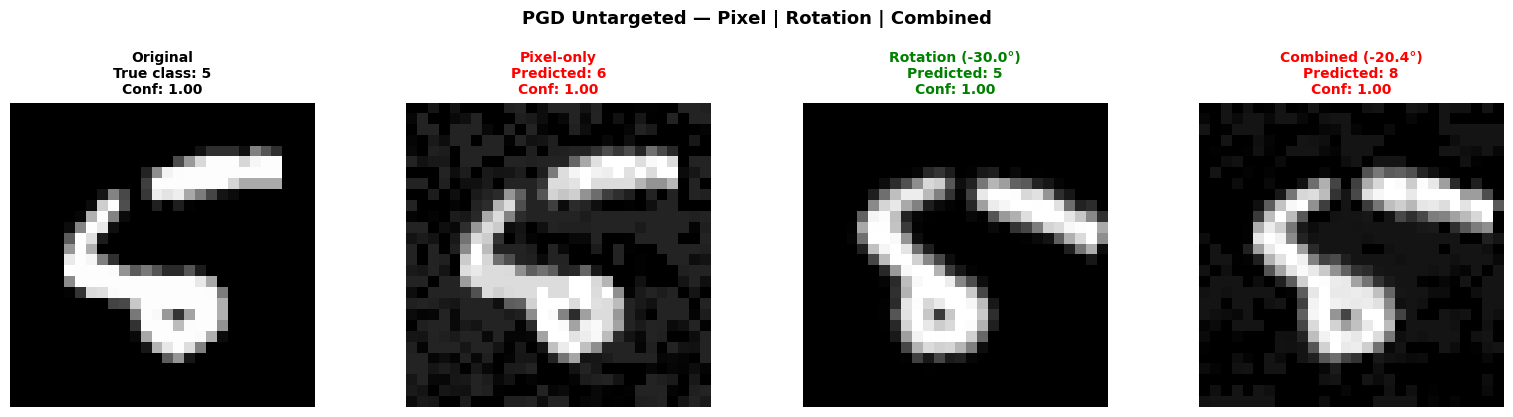


  Class      Original      Pixel   Rotation   Combined
  ───────────────────────────────────────────────────────
  Class 0:      0.00       0.00       0.00       0.00
  Class 1:      0.00       0.00       0.00       0.00
  Class 2:      0.00       0.00       0.00       0.00
  Class 3:      0.00       0.00       0.00       0.00
  Class 4:      0.00       0.00       0.00       0.00
  Class 5:      1.00       0.00       1.00       0.00 ◄ true
  Class 6:      0.00       1.00       0.00       0.00
  Class 7:      0.00       0.00       0.00       0.00
  Class 8:      0.00       0.00       0.00       1.00
  Class 9:      0.00       0.00       0.00       0.00


▶  PGD TARGETED — pushing prediction toward class 6



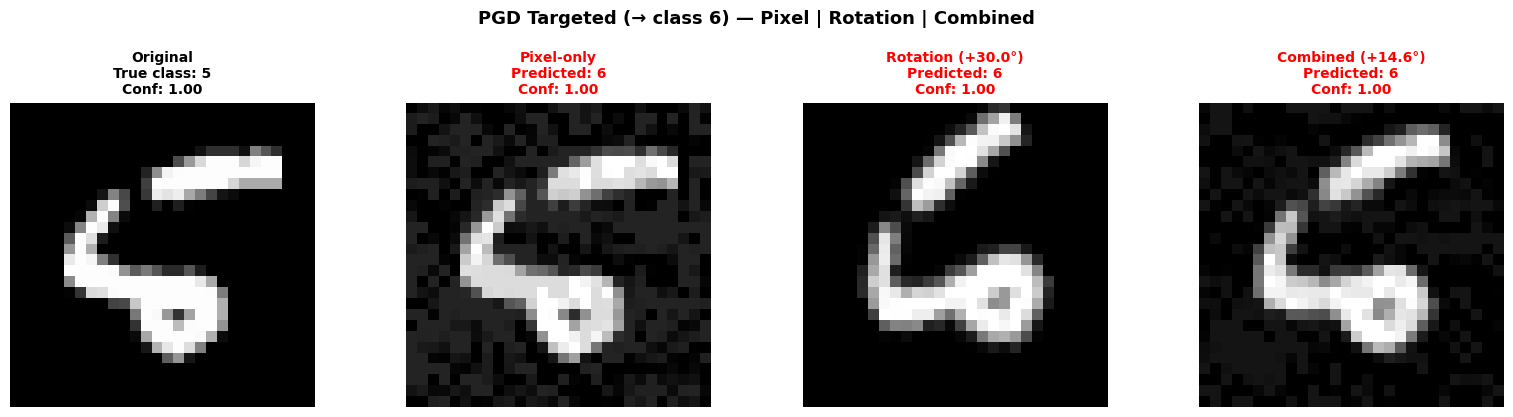


  Class      Original      Pixel   Rotation   Combined
  ───────────────────────────────────────────────────────
  Class 0:      0.00       0.00       0.00       0.00
  Class 1:      0.00       0.00       0.00       0.00
  Class 2:      0.00       0.00       0.00       0.00
  Class 3:      0.00       0.00       0.00       0.00
  Class 4:      0.00       0.00       0.00       0.00
  Class 5:      1.00       0.00       0.00       0.00 ◄ true
  Class 6:      0.00       1.00       1.00       1.00
  Class 7:      0.00       0.00       0.00       0.00
  Class 8:      0.00       0.00       0.00       0.00
  Class 9:      0.00       0.00       0.00       0.00



In [ ]:

"""
SRI Experiment 5 — Combined Adversarial Attack: Pixel + Rotation
=================================================================

WHAT IS NEW HERE vs Experiment 1?
──────────────────────────────────────────────────────────────────────
  Experiment 1 had TWO SEPARATE attacks:
    • Pixel attack   → optimize Δx (pixel noise), 784 numbers
    • Rotation attack → optimize θ  (angle),        1  number

  This file adds a COMBINED attack:
    • Optimize BOTH Δx AND θ together — 785 numbers at once

KEY IDEA:
  In PyTorch, one call to loss.backward() fills the .grad attribute
  for EVERY tensor that has requires_grad=True in the compute graph.

  So if we set:
        angle_var = tensor(0.0, requires_grad=True)     # 1 grad
        delta_var = zeros(1,1,28,28, requires_grad=True) # 784 grads

  … and then compute the forward pass through BOTH (rotate first,
  then add noise), a single backward() gives us:
        angle_var.grad   →  ∂L/∂θ   (1 number, direction to rotate)
        delta_var.grad   →  ∂L/∂Δx  (784 numbers, pixel perturbation)

  This lets FGSM / PGD update BOTH attributes simultaneously.
──────────────────────────────────────────────────────────────────────
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt


# ======================================================================
# HELPER: Differentiable Rotation
# ======================================================================
# This is the same rotate_image() from Experiment 1.
# ======================================================================

def rotate_image(x, angle_deg):
    """
    Rotate image x by angle_deg degrees using a differentiable
    affine transform.

    WHY DIFFERENTIABLE?
        Standard image rotation (like PIL/numpy) is NOT differentiable.
        That means you can't get ∂L/∂θ through it.

        PyTorch's F.affine_grid + F.grid_sample IS differentiable.
        So if angle_deg is a torch.Tensor with requires_grad=True,
        calling loss.backward() will fill angle_deg.grad = ∂L/∂θ.

    Args:
        x         : image tensor,  shape (1, 1, 28, 28)
        angle_deg : rotation angle.
                    Can be:  a plain Python float (no grad needed)
                             OR a torch.Tensor with requires_grad=True (for attacks)
    Returns:
        rotated image, same shape as x
    """
    device = x.device

    # Convert Python float → Tensor if needed
    if not isinstance(angle_deg, torch.Tensor):
        angle_deg = torch.tensor(float(angle_deg), dtype=torch.float32, device=device)
    else:
        angle_deg = angle_deg.to(device)

    # Convert degrees → radians
    angle_rad = angle_deg * (np.pi / 180.0)

    # Build the 2×3 rotation matrix:
    #   [ cos θ,  -sin θ,  0 ]
    #   [ sin θ,   cos θ,  0 ]
    cos_a = torch.cos(angle_rad).reshape(1)
    sin_a = torch.sin(angle_rad).reshape(1)
    zero  = torch.zeros(1, dtype=torch.float32, device=device)

    row1      = torch.cat([ cos_a, -sin_a, zero])
    row2      = torch.cat([ sin_a,  cos_a, zero])
    theta_mat = torch.stack([row1, row2]).unsqueeze(0)   # shape (1, 2, 3)

    # Warp the image using the rotation matrix
    grid    = F.affine_grid(theta_mat, x.size(), align_corners=False)
    rotated = F.grid_sample(x, grid, align_corners=False, padding_mode='zeros')
    return rotated


# ======================================================================
# COMBINED FGSM (one step)
# ======================================================================

def fgsm_combined_(model, x, target, eps_pixel, eps_deg,
                    targeted=True, clip_min=0.0, clip_max=1.0):
    """
    Combined FGSM: one gradient step on BOTH rotation angle AND pixels.

    COMPARE to the original fgsm_() which only touches pixels:

        Original fgsm_():
            input_.requires_grad_()           ← only Δx has grad
            loss.backward()                   ← fills input_.grad
            out = input_ ± eps * input_.grad.sign()

        Combined fgsm_combined_():
            angle_var.requires_grad_(True)    ← θ has grad
            delta_var.requires_grad_(True)    ← Δx has grad
            loss.backward()                   ← fills BOTH grads
            angle_adv = angle_var ± eps_deg   * angle_var.grad.sign()
            delta_adv = delta_var ± eps_pixel * delta_var.grad.sign()

    FORWARD PASS (the path the gradients travel back through):
        x_rotated  = rotate(x, angle_var)       ← depends on θ
        x_combined = x_rotated + delta_var       ← depends on Δx
        logits     = model(x_combined)
        loss       = CrossEntropy(logits, target)

    BACKWARD PASS (automatic — PyTorch chains all the gradients):
        loss → logits → x_combined → {x_rotated, delta_var}
                                          ↓               ↓
                                       angle_var       delta_var
                                        .grad            .grad

    Args:
        model     : neural network
        x         : original image, shape (1, 1, 28, 28)
        target    : target class (for targeted) or true label (for untargeted)
        eps_pixel : max pixel perturbation, e.g. 0.08  (values in [0,1])
        eps_deg   : max rotation angle in degrees, e.g. 30.0
        targeted  : True  → minimise loss → push TOWARD target class
                    False → maximise loss → push AWAY FROM true class
        clip_min  : clip output image to this lower bound (usually 0)
        clip_max  : clip output image to this upper bound (usually 1)

    Returns:
        adv       : adversarial image,         shape (1, 1, 28, 28)
        angle_adv : adversarial angle (float), how much we rotated
        delta_adv : adversarial pixel noise,   shape (1, 1, 28, 28)
    """

    # ── Start from zero: no rotation, no pixel noise ─────────────────
    # angle_var = θ,  starts at 0 (no rotation)
    # delta_var = Δx, starts at 0 (no pixel change)
    # Both have requires_grad=True so backward() fills their .grad
    angle_var = torch.tensor(0.0, requires_grad=True, dtype=torch.float32)
    delta_var = torch.zeros_like(x, requires_grad=True)

    # ── Forward pass ─────────────────────────────────────────────────
    # Step 1: rotate the image by the current angle
    x_rotated  = rotate_image(x, angle_var)

    # Step 2: add pixel perturbation on top of the rotated image
    x_combined = x_rotated + delta_var

    # Step 3: get model predictions and compute loss
    logits     = model(x_combined)
    target_t   = torch.LongTensor([target])
    model.zero_grad()
    loss       = nn.CrossEntropyLoss()(logits, target_t)

    # ── Backward pass ─────────────────────────────────────────────────
    # This single call fills:
    #   angle_var.grad = ∂L/∂θ   (how much loss changes if we change angle)
    #   delta_var.grad = ∂L/∂Δx  (how much loss changes per pixel)
    loss.backward()

    # ── FGSM update on both parameters ───────────────────────────────
    with torch.no_grad():
        if targeted:
            # TARGETED: we want the model to predict `target`
            # → we want to MINIMISE the loss for class `target`
            # → move in the NEGATIVE gradient direction
            angle_adv = angle_var - eps_deg   * angle_var.grad.sign()
            delta_adv = delta_var - eps_pixel * delta_var.grad.sign()
        else:
            # UNTARGETED: we just want to fool the model
            # → we want to MAXIMISE the loss for the true label
            # → move in the POSITIVE gradient direction
            angle_adv = angle_var + eps_deg   * angle_var.grad.sign()
            delta_adv = delta_var + eps_pixel * delta_var.grad.sign()

        # Build the adversarial image using the new angle + pixel noise
        x_rotated_adv = rotate_image(x.detach(), angle_adv)
        adv = (x_rotated_adv + delta_adv).clamp(clip_min, clip_max)

    return adv.detach(), angle_adv.item(), delta_adv.detach()


def fgsm_combined_targeted(model, x, target, eps_pixel, eps_deg, **kwargs):
    """Combined FGSM: steer prediction TOWARD `target` class."""
    return fgsm_combined_(model, x, target, eps_pixel, eps_deg,
                           targeted=True, **kwargs)

def fgsm_combined_untargeted(model, x, label, eps_pixel, eps_deg, **kwargs):
    """Combined FGSM: steer prediction AWAY FROM true `label`."""
    return fgsm_combined_(model, x, label, eps_pixel, eps_deg,
                           targeted=False, **kwargs)


# ======================================================================
# PART 2 — COMBINED PGD (iterative)
# ======================================================================

def pgd_combined_(model, x, target, k, eps_pixel, eps_step_pixel,
                   eps_deg, eps_step_deg,
                   targeted=True, clip_min=0.0, clip_max=1.0):
    """
    Combined PGD: k iterations of FGSM on BOTH angle AND pixels,
    with projection back to the allowed budgets after each step.

    COMPARE to the original pgd_() which only touches pixels:

        Original pgd_():
            δ  ~ Uniform(-ε, +ε)          ← random start for Δx only
            for k steps:
                x = fgsm_(x)              ← update Δx only
                x = clamp(x, x-ε, x+ε)   ← project Δx

        Combined pgd_combined_():
            δ  ~ Uniform(-ε_pix, +ε_pix)  ← random start for Δx
            θ  ~ Uniform(-ε_deg, +ε_deg)  ← random start for θ
            for k steps:
                angle, delta = fgsm step on BOTH    ← update both
                angle = clamp(angle, -ε_deg, +ε_deg) ← project θ
                delta = clamp(delta, -ε_pix, +ε_pix) ← project Δx

    WHY RANDOM START?
        PGD (Projected Gradient Descent) uses a random start point
        within the epsilon ball. This avoids getting stuck at a local
        optimum near zero. Multiple random restarts → stronger attack.

    WHY PROJECTION?
        After each step, the angle and pixel perturbation might
        exceed the budget (e.g., angle might grow to 150° after
        many steps). We clamp them back to the budget bounds.

    Args:
        model          : neural network
        x              : original image, shape (1, 1, 28, 28)
        target         : target class (targeted) or true label (untargeted)
        k              : number of PGD iterations, e.g. 20
        eps_pixel      : total pixel budget, e.g. 0.08
        eps_step_pixel : pixel step size per iteration, e.g. 0.01
        eps_deg        : total rotation budget in degrees, e.g. 30.0
        eps_step_deg   : rotation step size per iteration, e.g. 3.0
        targeted       : True  → push toward target class
                         False → push away from true class

    Returns:
        adv       : adversarial image,         shape (1, 1, 28, 28)
        angle_adv : final adversarial angle (float)
        delta_adv : final pixel noise,         shape (1, 1, 28, 28)
    """

    # ── Random start within budget bounds ────────────────────────────
    # angle: uniform in [-eps_deg, +eps_deg]
    # delta: uniform in [-eps_pixel, +eps_pixel]
    angle = torch.FloatTensor(1).uniform_(-eps_deg,   eps_deg)
    delta = (2 * torch.rand_like(x) - 1) * eps_pixel

    # ── k iterations of (FGSM step + projection) ─────────────────────
    for step in range(k):

        # Clone and re-attach requires_grad each step.
        # WHY? After each update, we do detach() to break the
        # old compute graph. We need a fresh graph for backward()
        # in the next step.
        angle_var = angle.clone().detach().requires_grad_(True)
        delta_var = delta.clone().detach().requires_grad_(True)

        # Forward pass
        x_rotated  = rotate_image(x, angle_var)
        x_combined = x_rotated + delta_var
        logits     = model(x_combined)
        target_t   = torch.LongTensor([target])
        model.zero_grad()
        loss       = nn.CrossEntropyLoss()(logits, target_t)

        # Backward pass → fills angle_var.grad and delta_var.grad
        loss.backward()

        with torch.no_grad():
            if targeted:
                angle = angle_var - eps_step_deg   * angle_var.grad.sign()
                delta = delta_var - eps_step_pixel * delta_var.grad.sign()
            else:
                angle = angle_var + eps_step_deg   * angle_var.grad.sign()
                delta = delta_var + eps_step_pixel * delta_var.grad.sign()

            # PROJECTION — clamp both back to their allowed budgets
            # Without this, the angle might grow to 300° or the pixel
            # noise might become very large, which is "cheating"
            angle = angle.clamp(-eps_deg,   +eps_deg)
            delta = delta.clamp(-eps_pixel, +eps_pixel)

    # ── Build the final adversarial image ────────────────────────────
    with torch.no_grad():
        x_rotated_adv = rotate_image(x.detach(), angle.detach())
        adv = (x_rotated_adv + delta.detach()).clamp(clip_min, clip_max)

    return adv.detach(), angle.item(), delta.detach()


def pgd_combined_targeted(model, x, target, k, eps_pixel, eps_step_pixel,
                            eps_deg, eps_step_deg, **kwargs):
    """Combined PGD: steer prediction TOWARD `target` class."""
    return pgd_combined_(model, x, target, k, eps_pixel, eps_step_pixel,
                          eps_deg, eps_step_deg, targeted=True, **kwargs)

def pgd_combined_untargeted(model, x, label, k, eps_pixel, eps_step_pixel,
                              eps_deg, eps_step_deg, **kwargs):
    """Combined PGD: steer prediction AWAY FROM true `label`."""
    return pgd_combined_(model, x, label, k, eps_pixel, eps_step_pixel,
                          eps_deg, eps_step_deg, targeted=False, **kwargs)


# ======================================================================
# PART 3 — VISUALIZATION
# ======================================================================

def show_comparison(original, adv_pixel, adv_rot, adv_combined,
                     angle_rot, angle_combined,
                     model_to_prob, title=""):
    """
    Show 4 images side-by-side:
        Original | Pixel-only attack | Rotation-only attack | Combined attack

    Titles are colored:
        Black  = the true class (no fooling needed)
        Green  = attack FAILED  (model still predicted correctly)
        Red    = attack SUCCEEDED (model was fooled)

    Also prints a probability table comparing all 4.
    """
    # Get model probabilities for all 4 images
    p0   = model_to_prob(original).detach().numpy()
    p_px = model_to_prob(adv_pixel).detach().numpy()
    p_ro = model_to_prob(adv_rot).detach().numpy()
    p_co = model_to_prob(adv_combined).detach().numpy()
    true_class = int(p0.argmax())

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    images = [original, adv_pixel, adv_rot, adv_combined]
    probs  = [p0, p_px, p_ro, p_co]
    titles = [
        f"Original\nTrue class: {true_class}\nConf: {p0.max():.2f}",
        f"Pixel-only\nPredicted: {p_px.argmax()}\nConf: {p_px.max():.2f}",
        f"Rotation ({angle_rot:+.1f}°)\nPredicted: {p_ro.argmax()}\nConf: {p_ro.max():.2f}",
        f"Combined ({angle_combined:+.1f}°)\nPredicted: {p_co.argmax()}\nConf: {p_co.max():.2f}",
    ]
    # Color the title: first image always black, others red=fooled, green=failed
    title_colors = [
        'black',
        'red'  if p_px.argmax() != true_class else 'green',
        'red'  if p_ro.argmax() != true_class else 'green',
        'red'  if p_co.argmax() != true_class else 'green',
    ]

    for ax, img, ttl, col in zip(axes, images, titles, title_colors):
        ax.imshow(img.detach().numpy().reshape(28, 28), cmap='gray')
        ax.set_title(ttl, fontsize=10, color=col, fontweight='bold')
        ax.axis('off')

    if title:
        plt.suptitle(title, fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()

    # ── Print probability table ───────────────────────────────────────
    print(f"\n  {'Class':<8} {'Original':>10} {'Pixel':>10} {'Rotation':>10} {'Combined':>10}")
    print("  " + "─" * 55)
    for i in range(10):
        true_tag = " ◄ true" if i == true_class else ""
        print(f"  Class {i}: "
              f"{float(p0[:,i]):>9.2f} "
              f"{float(p_px[:,i]):>10.2f} "
              f"{float(p_ro[:,i]):>10.2f} "
              f"{float(p_co[:,i]):>10.2f}"
              f"{true_tag}")
    print()


# ======================================================================
# PART 4 — DEMO (single image, all attacks)
# ======================================================================

# ── Shared hyperparameters ────────────────────────────────────────────
# Using the SAME budgets for both individual and combined attacks.
# This makes the comparison fair — combined is not cheating by
# using a larger budget, it's just using BOTH budgets at once.
EPS_PIXEL      = 0.08    # pixel budget: max ±0.08 per pixel
EPS_DEG        = 30.0    # rotation budget: max ±30°
K              = 20      # PGD iterations
EPS_STEP_PIX   = 0.01    # pixel PGD step size per iteration
EPS_STEP_DEG   = 3.0     # rotation PGD step size per iteration (°)

original   = torch.unsqueeze(test_dataset[8][0], dim=0)
true_label = test_dataset[8][1]
print(f"Selected image true label: {true_label}")
print("=" * 65)

# ──────────────────────────────────────────────────────────────────────
# FGSM comparison (one-step attacks)
# ──────────────────────────────────────────────────────────────────────
print("\n▶  FGSM UNTARGETED — Pixel vs Rotation vs Combined\n")

# 1. Pixel-only FGSM (from Experiment 1)
adv_pixel_fgsm = fgsm_untargeted(model, original, label=true_label,
                                   eps=EPS_PIXEL, clip_min=0, clip_max=1.0)

# 2. Rotation-only FGSM (from Experiment 1)
adv_rot_fgsm, angle_rot_fgsm = fgsm_rotation_untargeted(
    model, original, label=true_label, eps_deg=EPS_DEG)

# 3. Combined FGSM (NEW — from this file)
adv_comb_fgsm, angle_comb_fgsm, _ = fgsm_combined_untargeted(
    model, original, label=true_label,
    eps_pixel=EPS_PIXEL, eps_deg=EPS_DEG,
    clip_min=0, clip_max=1.0)

show_comparison(
    original, adv_pixel_fgsm, adv_rot_fgsm, adv_comb_fgsm,
    angle_rot_fgsm, angle_comb_fgsm, model_to_prob,
    title="FGSM Untargeted — Pixel | Rotation | Combined"
)

# ──────────────────────────────────────────────────────────────────────
# PGD comparison (iterative attacks)
# ──────────────────────────────────────────────────────────────────────
print("\n▶  PGD UNTARGETED — Pixel vs Rotation vs Combined\n")

# 1. Pixel-only PGD (from Experiment 1)
adv_pixel_pgd = pgd_untargeted(model, original, label=true_label,
                                 k=K, eps=EPS_PIXEL, eps_step=EPS_STEP_PIX,
                                 clip_min=0, clip_max=1.0)

# 2. Rotation-only PGD (from Experiment 1)
adv_rot_pgd, angle_rot_pgd = pgd_rotation_untargeted(
    model, original, label=true_label,
    k=K, eps_deg=EPS_DEG, eps_step_deg=EPS_STEP_DEG)

# 3. Combined PGD (NEW — from this file)
adv_comb_pgd, angle_comb_pgd, _ = pgd_combined_untargeted(
    model, original, label=true_label,
    k=K, eps_pixel=EPS_PIXEL, eps_step_pixel=EPS_STEP_PIX,
    eps_deg=EPS_DEG, eps_step_deg=EPS_STEP_DEG,
    clip_min=0, clip_max=1.0)

show_comparison(
    original, adv_pixel_pgd, adv_rot_pgd, adv_comb_pgd,
    angle_rot_pgd, angle_comb_pgd, model_to_prob,
    title="PGD Untargeted — Pixel | Rotation | Combined"
)


# ──────────────────────────────────────────────────────────────────────
# Targeted example: try to make the model predict class 3
# ──────────────────────────────────────────────────────────────────────
TARGET_CLASS = 6
print(f"\n▶  PGD TARGETED — pushing prediction toward class {TARGET_CLASS}\n")

adv_pixel_t = pgd_targeted(model, original, target=TARGET_CLASS,
                             k=K, eps=EPS_PIXEL, eps_step=EPS_STEP_PIX,
                             clip_min=0, clip_max=1.0)

adv_rot_t, angle_rot_t = pgd_rotation_targeted(
    model, original, target=TARGET_CLASS,
    k=K, eps_deg=EPS_DEG, eps_step_deg=EPS_STEP_DEG)

adv_comb_t, angle_comb_t, _ = pgd_combined_targeted(
    model, original, target=TARGET_CLASS,
    k=K, eps_pixel=EPS_PIXEL, eps_step_pixel=EPS_STEP_PIX,
    eps_deg=EPS_DEG, eps_step_deg=EPS_STEP_DEG,
    clip_min=0, clip_max=1.0)

show_comparison(
    original, adv_pixel_t, adv_rot_t, adv_comb_t,
    angle_rot_t, angle_comb_t, model_to_prob,
    title=f"PGD Targeted (→ class {TARGET_CLASS}) — Pixel | Rotation | Combined"
)
